In [18]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset,DataLoader 
from torchsummary import summary 
from sklearn.model_selection import train_test_split   
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np


In [19]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

True
NVIDIA GeForce RTX 4050 Laptop GPU
cuda


In [20]:
df=pd.read_csv('riceClassification.csv')
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [21]:
df.dropna(inplace=True)
df.drop(['id'],axis=1,inplace=True)

In [22]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [23]:
df['Class'].unique()

array([1, 0])

In [24]:
df['Class'].value_counts()

Class
1    9985
0    8200
Name: count, dtype: int64

In [25]:
original_df=df.copy() # A backup

In [26]:
for column in df.columns:
    df[column]=df[column]/df[column].abs().max()

In [27]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             18185 non-null  float64
 1   MajorAxisLength  18185 non-null  float64
 2   MinorAxisLength  18185 non-null  float64
 3   Eccentricity     18185 non-null  float64
 4   ConvexArea       18185 non-null  float64
 5   EquivDiameter    18185 non-null  float64
 6   Extent           18185 non-null  float64
 7   Perimeter        18185 non-null  float64
 8   Roundness        18185 non-null  float64
 9   AspectRation     18185 non-null  float64
 10  Class            18185 non-null  float64
dtypes: float64(11)
memory usage: 1.5 MB


In [28]:
X=np.array(df.iloc[:,:-1])
y=np.array(df.iloc[:,-1])


In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
X_test,X_val,y_test,y_val=train_test_split(X_test,y_test,test_size=0.5)

In [30]:
print(X_train,X_train.shape)

[[0.89529873 0.88955948 0.87110334 ... 0.74915194 0.87485338 0.57936893]
 [0.91958864 0.88707606 0.90536943 ... 0.77750727 0.83424152 0.55588495]
 [0.88237023 0.8862491  0.87243336 ... 0.776701   0.80214012 0.57633292]
 ...
 [0.64652302 0.68976794 0.82166711 ... 0.61814592 0.92791693 0.47627413]
 [0.63506366 0.80419295 0.69000631 ... 0.66395221 0.79004303 0.6612369 ]
 [0.83643487 0.85961728 0.84357494 ... 0.74186202 0.83347575 0.57813778]] (12729, 10)


In [31]:
class dataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32).to(device)
        self.y=torch.tensor(y,dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self,index):
        return self.X[index],self.y[index]

In [32]:
train_data=dataset(X_train,y_train)
val_data=dataset(X_val,y_val)
test_data=dataset(X_test,y_test)

In [33]:
train_dataloader=DataLoader(train_data,batch_size=32,shuffle=True, drop_last=True)
val_dataloader=DataLoader(val_data,batch_size=32,shuffle=True, drop_last=True)
test_dataloader=DataLoader(test_data,batch_size=32,shuffle=True, drop_last=True)


In [34]:
# Task of a DataLoader (Batch Size =8 , 8 rows & 8 columns)
for x,y in train_dataloader:
    print(x)
    print('------------')
    print(y)
    break

tensor([[0.9219, 0.8875, 0.9041, 0.9190, 0.8877, 0.9602, 0.7588, 0.7779, 0.8354,
         0.5569],
        [0.6213, 0.8146, 0.6616, 0.9626, 0.5878, 0.7882, 0.8167, 0.6614, 0.7789,
         0.6985],
        [0.5520, 0.7719, 0.6253, 0.9630, 0.5214, 0.7430, 0.5699, 0.6261, 0.7724,
         0.7003],
        [0.7594, 0.8257, 0.8029, 0.9298, 0.7248, 0.8714, 0.6246, 0.7047, 0.8385,
         0.5835],
        [0.8597, 0.8505, 0.8747, 0.9166, 0.8139, 0.9272, 0.8571, 0.7368, 0.8686,
         0.5516],
        [0.5894, 0.9095, 0.5650, 0.9930, 0.5677, 0.7677, 0.5316, 0.7268, 0.6120,
         0.9133],
        [0.7889, 0.8304, 0.8261, 0.9246, 0.7510, 0.8882, 0.6807, 0.7138, 0.8492,
         0.5703],
        [0.9298, 0.9074, 0.8957, 0.9264, 0.8921, 0.9642, 0.6729, 0.7793, 0.8396,
         0.5747],
        [0.6162, 0.8939, 0.6055, 0.9850, 0.5876, 0.7850, 0.6981, 0.6990, 0.6916,
         0.8375],
        [0.5671, 0.6698, 0.7444, 0.8953, 0.5392, 0.7531, 0.8848, 0.5922, 0.8868,
         0.5105],
        [0

In [ ]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel,self).__init__()

        self.inpu_layer=nn.Linear(in_features=X.shape[1],out_features=128) #input
        self.linear1=nn.Linear(in_features=128,out_features=10)  # hidden layer 1
        self.dropout1 = nn.Dropout(0.5)   #Dropout
        self.linear2=nn.Linear(in_features=10,out_features=1) #hidden layer 2
        self.out_layer=nn.Sigmoid() #Output layer 

    def forward(self,x):
        x=self.inpu_layer(x)
        x=torch.relu(self.linear1(x))
        x = self.dropout1(x) 
        x=torch.relu(self.linear2(x))
        x=self.out_layer(x)
        return x
    
    

In [46]:
X.shape[0]

18185

In [47]:
model=MyModel().to(device)

In [48]:
summary(model,(X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]           1,408
            Linear-2                   [-1, 10]           1,290
           Dropout-3                   [-1, 10]               0
            Linear-4                    [-1, 1]              11
           Sigmoid-5                    [-1, 1]               0
Total params: 2,709
Trainable params: 2,709
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


In [49]:
criterion=nn.BCELoss()
optimizer=Adam(model.parameters(),lr=1e-3)

In [50]:
total_loss_train_plot=[]
total_loss_val_plot=[]
total_acc_train_plot=[]
total_acc_val_plot=[]


epochs=100
for epoch in range(epochs):
    total_acc_train=0
    total_loss_train=0
    total_acc_val=0
    total_loss_val=0

    for data in train_dataloader:
        inputs,labels=data

        prediction=model(inputs).squeeze(1)
        
        batch_loss=criterion(prediction,labels)
        total_loss_train+=batch_loss.item()

        acc=((prediction).round()==labels).sum().item()
        total_acc_train+=acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for data in val_dataloader:
            inputs,label=data
            prediction=model(inputs).squeeze(1)
            batch_loss=criterion(prediction,label)
            total_loss_val+=batch_loss.item()

            acc=((prediction).round()==labels).sum().item()
            total_acc_val+=acc

    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_val_plot.append(round(total_loss_val/1000,4))
    total_acc_train_plot.append(round(total_acc_train/train_data.__len__()*100,4))
    total_acc_val_plot.append(round(total_acc_val/val_data.__len__()*100,4))

    print(f'''Epoch Number {epoch +1}  Train Loss:{round(total_loss_train/1000,4)}
            Train Accuracy:{round(total_acc_train/train_data.__len__()*100,4)} 
            Validation loss:{round(total_loss_val/1000,4)}
            Validation Accuracy:{round(total_acc_val/val_data.__len__()*100,4)}''')
    print("="*25)



Epoch Number 1  Train Loss:0.2344
            Train Accuracy:69.2592 
            Validation loss:0.0385
            Validation Accuracy:47.8372
Epoch Number 2  Train Loss:0.1776
            Train Accuracy:77.4059 
            Validation loss:0.0364
            Validation Accuracy:49.5968
Epoch Number 3  Train Loss:0.1724
            Train Accuracy:84.2721 
            Validation loss:0.035
            Validation Accuracy:49.7801
Epoch Number 4  Train Loss:0.1732
            Train Accuracy:83.9972 
            Validation loss:0.0361
            Validation Accuracy:46.1877
Epoch Number 5  Train Loss:0.1725
            Train Accuracy:84.2329 
            Validation loss:0.0363
            Validation Accuracy:47.7639
Epoch Number 6  Train Loss:0.1719
            Train Accuracy:84.7121 
            Validation loss:0.0359
            Validation Accuracy:47.6173
Epoch Number 7  Train Loss:0.1712
            Train Accuracy:84.8928 
            Validation loss:0.0354
            Validation Acc

In [51]:
with torch.no_grad():
    total_loss_test=0
    total_acc_test=0

    for inputs,label in test_dataloader:
        prediction=model(inputs).squeeze(1)
        batch_loss_test=criterion(prediction,label).item()
        total_loss_test+=batch_loss_test
        acc=((prediction).round()==labels).sum().item()
        total_acc_test+=acc

print(f"Accuracy {round(total_acc_test/test_data.__len__()*100,4)}")



Accuracy 51.0264


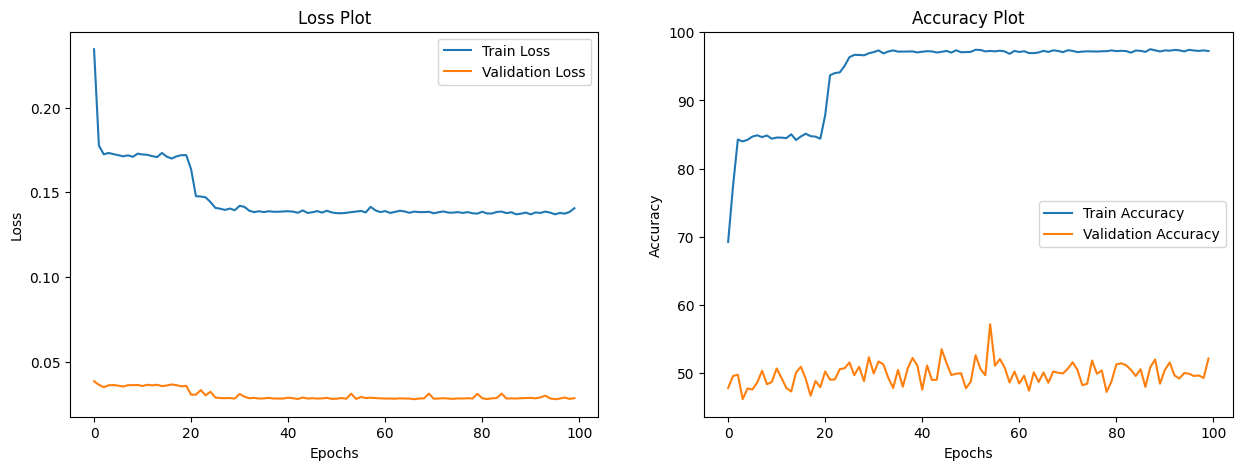

In [52]:
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
axs[0].plot(total_loss_train_plot,label='Train Loss')
axs[0].plot(total_loss_val_plot,label='Validation Loss')
axs[0].set_title('Loss Plot')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_acc_train_plot,label='Train Accuracy')
axs[1].plot(total_acc_val_plot,label='Validation Accuracy')
axs[1].set_title('Accuracy Plot')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.show()